<a href="https://colab.research.google.com/github/JMCVALE/ASN-ROCKS-/blob/main/SERIES_TEMPORAIS_Previs%C3%A3o_de_Vendas_diarias.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Trabalho: Previsão de Vendas diária**

O objetivo principal é transformar dados transacionais em uma série temporal e realizar a previsão de vendas diárias para um departamento específico.

**1. Preparação dos Dados (Data Prep):**

Agregação: Converter as transações em uma série diária, utilizando a soma do valor das vendas como método de acumulação.

*   Saneamento
*   Datas Faltantes: Identificar lacunas no calendário e preenchê-las (imputação ou zero) para garantir que a série seja igualmente espaçada.
*  Vendas Negativas: Tratar valores negativos (erros de registro) por meio de imputação, como a média do período.

Foco da Análise: Priorizar os Departamentos 2 ou 4, que juntos representam cerca de 95% do faturamento total.

**2. Estratégia de Modelagem:**

Divisão da Base: Utilizar os anos de 2018, 2019 e 2020 para treino e o ano de 2021 para teste (Holdout).

Análise Inicial:

* Visualização: Plotar recortes da série para identificar tendência e sazonalidade.

* Testes Estatísticos: Validar se a série é Ruído Branco (se for, não há padrão para prever) e verificar a Estacionariedade.

**3. Execução e Avaliação:**

Escolha do Modelo: Identificar se há tendência e sazonalidade para selecionar a técnica adequada (Alisamento Exponencial Simples, Holt ou Holt-Winters).

Validação:
* Comparar os valores previstos com os reais da base de teste (2021).

* Calcular métricas de erro (como o MAPE) e garantir que os resíduos do modelo se comportem como ruído branco, provando que o sinal foi capturado corretamente.
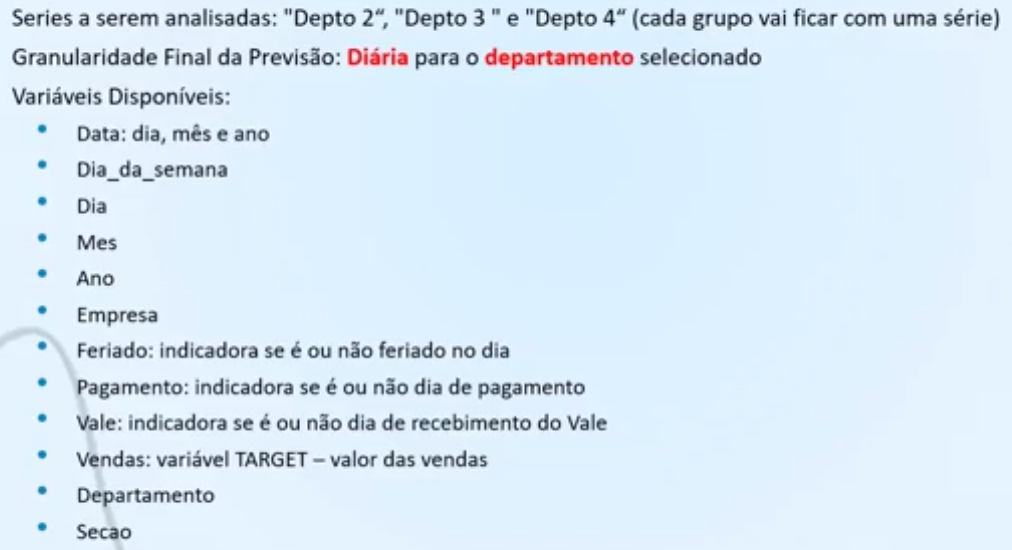

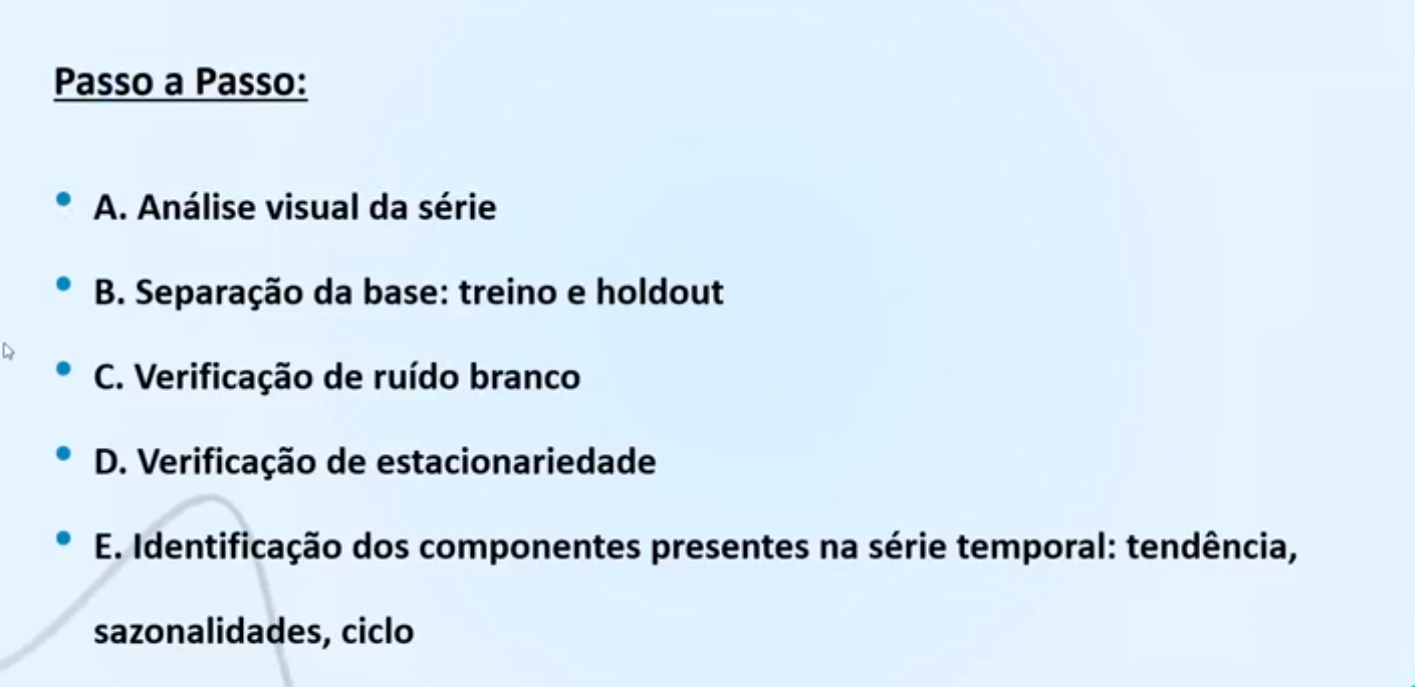

BIBLIOTECAS

In [3]:
from dateutil.parser import parse
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
plt.rcParams.update({'figure.figsize': (10, 7), 'figure.dpi': 120})

import dateutil
import calendar

import matplotlib.pyplot as plt
print('✅ Bibliotecas carregadas!')

✅ Bibliotecas carregadas!


1. CARREGAR DADOS

In [4]:
!pip install gdown # ponte entre Google Drive e Python

In [5]:
import gdown

file_id = "1wJBE7re7rSQ-ZhIyrAXjEA6rt5WGxBQW"

gdown.download(
    f"https://drive.google.com/uc?id={file_id}",
    "Vendas_ASN_Dados_Finais.csv",
    quiet=False
)

Downloading...
From: https://drive.google.com/uc?id=1wJBE7re7rSQ-ZhIyrAXjEA6rt5WGxBQW
To: /content/Vendas_ASN_Dados_Finais.csv
100%|██████████| 21.4M/21.4M [00:00<00:00, 158MB/s]


'Vendas_ASN_Dados_Finais.csv'

In [7]:
data = pd.read_csv('Vendas_ASN_Dados_Finais.csv')
data.head(10)

,Data,Data_new,Dia_da_semana,Dia,Mes,Ano,Empresa,Feriado,Pagamento,Vale,Vendas,Departamento,Seção
0,01/02/18,1/2/2018,3,2,1,2018,1,0,0,0,316.58,Depto 1,Seção 1
1,01/02/18,1/2/2018,3,2,1,2018,1,0,0,0,"94,195.95",Depto 2,Seção 2
2,01/02/18,1/2/2018,3,2,1,2018,1,0,0,0,"60,170.14",Depto 2,Seção 3
3,01/02/18,1/2/2018,3,2,1,2018,1,0,0,0,"48,120.35",Depto 2,Seção 4
4,01/02/18,1/2/2018,3,2,1,2018,2,0,0,0,"2,622.62",Depto 3,Seção 7
5,01/02/18,1/2/2018,3,2,1,2018,5,0,0,0,"21,277.82",Depto 2,Seção 26
6,01/02/18,1/2/2018,3,2,1,2018,1,0,0,0,155.12,Depto 3,Seção 5
7,01/02/18,1/2/2018,3,2,1,2018,1,0,0,0,"9,963.10",Depto 3,Seção 6
8,01/02/18,1/2/2018,3,2,1,2018,1,0,0,0,"18,400.85",Depto 3,Seção 7
9,01/02/18,1/2/2018,3,2,1,2018,1,0,0,0,"5,114.59",Depto 3,Seção 8


2. TRANSFORMAR DADOS TRANSACIONAIS EM AGREGADOS

In [13]:
# QUANTAS VENDAS TEM POR DEPARTAMENTO?

total_departamento = (
    data.groupby('Departamento', as_index=False)['Vendas']
      .sum()
)

# Total geral
total_geral = total_departamento['Vendas'].sum()

# Percentual de participação
total_departamento['Perc'] = (
    total_departamento['Vendas'] / total_geral * 100
)

# Valor em milhões
total_departamento['Vendas_MM'] = (
    total_departamento['Vendas'] / 1_000_000
)

# Formatação
total_departamento['Vendas_MM'] = (
    total_departamento['Vendas_MM']
    .map(lambda x: f'{x:,.2f} MM')
)

total_departamento['Perc'] = (
    total_departamento['Perc']
    .map(lambda x: f'{x:.2f}%')
)

print(total_departamento)

  Departamento        Vendas    Perc    Vendas_MM
0      Depto 1  5.295840e+06   0.09%      5.30 MM
1      Depto 2  3.265787e+09  54.12%  3,265.79 MM
2     Depto 3   2.474437e+08   4.10%    247.44 MM
3      Depto 4  2.460234e+09  40.77%  2,460.23 MM
4      Depto 5  5.052954e+07   0.84%     50.53 MM
5      Depto 6  4.219464e+06   0.07%      4.22 MM
6      Depto 7  9.759944e+05   0.02%      0.98 MM


Para continuar a análise, foi escolhido o departamento 4 por representar 41% das vendas.

In [14]:
data_depto4 = data[data['Departamento'] == 'Depto 4'].copy()

data_depto4['Vendas'] = (
    data_depto4['Vendas']
    .astype(str)
    .str.replace(',', '', regex=False)
    .astype(float)
)

In [15]:
vendas_dia = (
    data_depto4.groupby(['Data_new'])['Vendas']
      .sum()
      .reset_index()
)

print(vendas_dia)

       Data_new      Vendas
0     1/10/2018  1667902.81
1     1/10/2019  1659973.46
2     1/10/2020  2379917.22
3     1/10/2021  2084269.44
4     1/11/2018  1457775.73
...         ...         ...
1143   9/8/2019  1697660.95
1144   9/8/2020  2707879.60
1145   9/9/2018  1194290.31
1146   9/9/2019  1749338.91
1147   9/9/2020  2242961.30

[1148 rows x 2 columns]


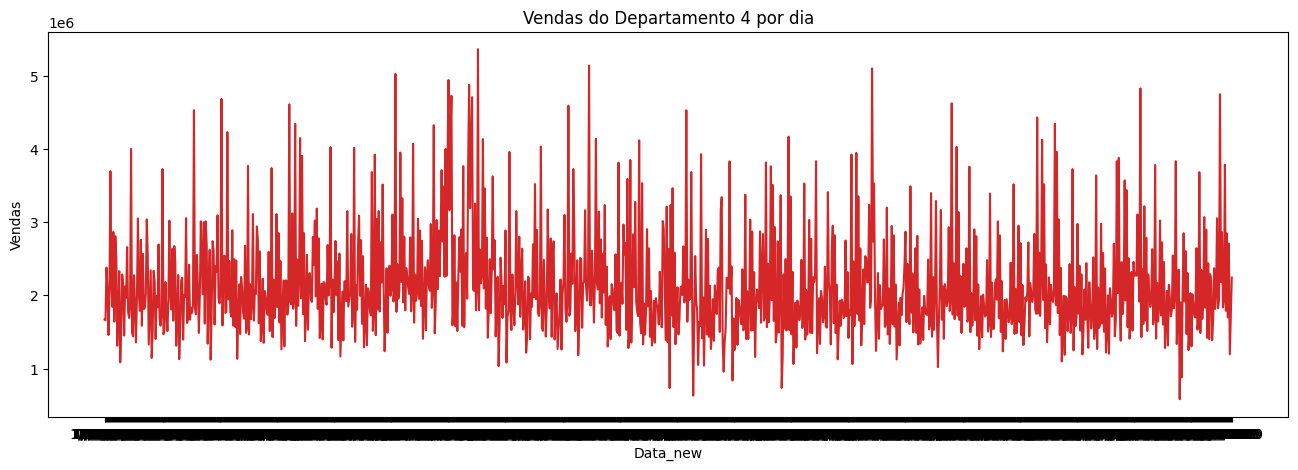

In [17]:
# Visualizando a série temporal

def plot_df(vendas_dia, x, y, title="", xlabel='Data_new', ylabel='Vendas', dpi=100):
    plt.figure(figsize=(16,5), dpi=dpi)
    plt.plot(x, y, color='tab:red')
    plt.gca().set(title=title, xlabel=xlabel, ylabel=ylabel)
    plt.show()

plot_df(vendas_dia=vendas_dia, x=vendas_dia.Data_new, y=vendas_dia.Vendas,
        title='Vendas do Departamento 4 por dia')

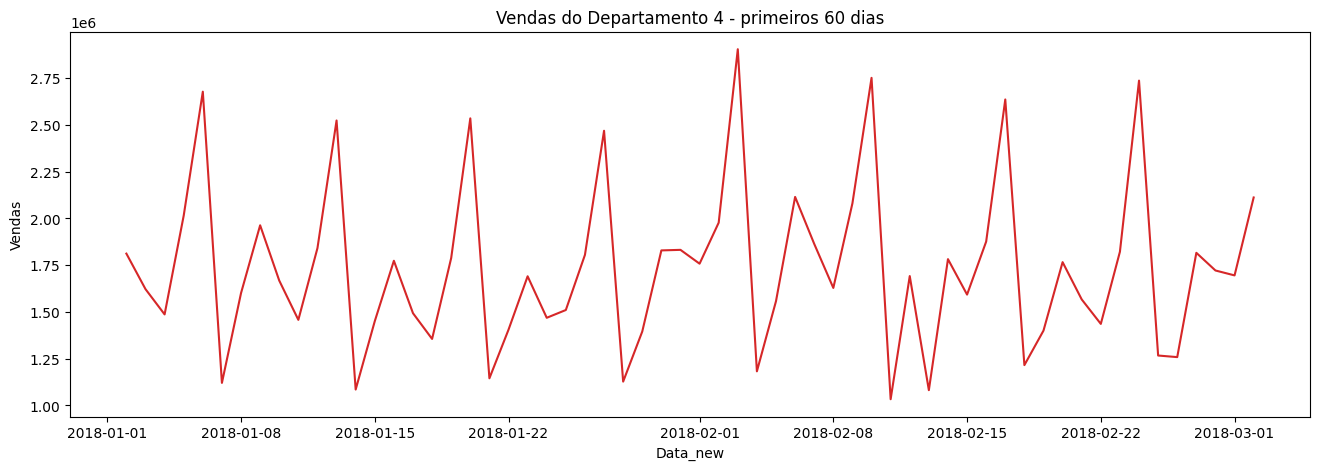

In [22]:
# Visualizando a série temporal em um intervalo de tempo menor

vendas_dia = vendas_dia.sort_values('Data_new')

trecho = vendas_dia.iloc[:60]

plot_df(
    vendas_dia=trecho,
    x=trecho['Data_new'],
    y=trecho['Vendas'],
    title='Vendas do Departamento 4 - primeiros 60 dias'
)

A série temporal apresenta comportamento predominantemente estacionário, sem tendência definida no período analisado. Observam-se oscilações diárias em torno de um nível médio aproximadamente constante, acompanhadas de elevada variabilidade e indícios de sazonalidade de curta duração, possivelmente semanal.

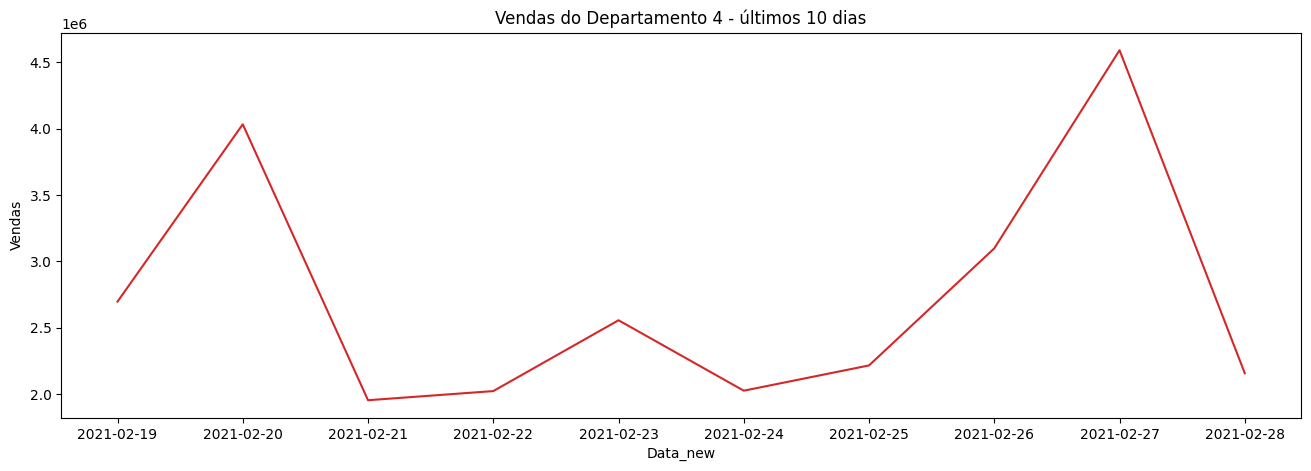

In [26]:
trecho = vendas_dia.iloc[-10:]

plot_df(
    vendas_dia=trecho,
    x=trecho['Data_new'],
    y=trecho['Vendas'],
    title='Vendas do Departamento 4 - últimos 10 dias'
)

In [27]:
# Tem dias faltantes?
datas_completas = pd.date_range(
    start=vendas_dia['Data_new'].min(),
    end=vendas_dia['Data_new'].max(),
    freq='D'
)

faltantes = datas_completas.difference(vendas_dia['Data_new'])

print(faltantes)
print('Quantidade de dias faltantes:', len(faltantes))

DatetimeIndex(['2018-12-25', '2019-01-01', '2019-12-25', '2020-01-01',
               '2020-12-25', '2021-01-01'],
              dtype='datetime64[ns]', freq=None)
Quantidade de dias faltantes: 6


In [28]:
# Imputar dias faltantes pela média do dia da semana no mes/ano

# Garantir formato datetime
vendas_dia['Data_new'] = pd.to_datetime(vendas_dia['Data_new'])

# Criar calendário completo
datas = pd.date_range(
    vendas_dia['Data_new'].min(),
    vendas_dia['Data_new'].max(),
    freq='D'
)

# Inserir datas faltantes
serie = (
    vendas_dia
    .set_index('Data_new')
    .reindex(datas)
    .rename_axis('Data_new')
    .reset_index()
)

# Variáveis auxiliares
serie['Ano'] = serie['Data_new'].dt.year
serie['Mes'] = serie['Data_new'].dt.month
serie['DiaSemana'] = serie['Data_new'].dt.dayofweek

# Marcar observações originalmente faltantes
serie['Imputado'] = serie['Vendas'].isna()

# Média do mesmo dia da semana dentro do mesmo mês/ano
serie['Media_DS'] = (
    serie
    .groupby(['Ano','Mes','DiaSemana'])['Vendas']
    .transform('mean')
)

# Imputação
serie['Vendas'] = serie['Vendas'].fillna(serie['Media_DS'])

# Remover coluna auxiliar
serie.drop(columns='Media_DS', inplace=True)

In [29]:
serie.loc[serie['Imputado'], ['Data_new','Vendas']]

,Data_new,Vendas
357,2018-12-25,2.103518e+06
364,2019-01-01,2.127077e+06
722,2019-12-25,2.048224e+06
729,2020-01-01,2.024906e+06
1088,2020-12-25,3.006982e+06
1095,2021-01-01,2.875630e+06


In [30]:
serie['Vendas'].isna().sum()

np.int64(0)